# 第三章配套代码：策略评价与风险管理

本 notebook 对应 `03_evaluation.md`，依次生成讲义中引用的所有图表。

**运行前请确认**：
- 已安装：`baostock`, `pandas`, `numpy`, `scipy`, `statsmodels`, `matplotlib`, `seaborn`, `vectorbt`, `quantstats`
- `data/stock/` 目录下已有前两章下载的数据

安装：`pip install quantstats seaborn vectorbt`

## 第0节　环境设置与数据加载

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.api as sm

warnings.filterwarnings('ignore')

import matplotlib, platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Microsoft YaHei')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='PingFang SC')
else:
    matplotlib.rc('font', family='WenQuanYi Micro Hei')
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['savefig.bbox'] = 'tight'

os.makedirs('figs', exist_ok=True)

TRADING_DAYS = 252
RF_ANNUAL    = 0.02
RF_DAILY     = RF_ANNUAL / TRADING_DAYS
FEES         = 0.002

# ------------------------------------------------------------------
# 辅助函数：从收盘价序列生成双均线策略净值
# ------------------------------------------------------------------
def ma_strategy_nav(price, n1, n2, fees=FEES, init_cash=1.0):
    """向量化双均线策略，返回净值序列。
    n1: 短期均线，n2: 长期均线。
    使用 shift(1) 确保信号在次日才生效，避免未来函数。
    """
    ma_s = price.rolling(n1).mean()
    ma_l = price.rolling(n2).mean()
    # 持仓状态：1=持有，0=空仓
    raw_signal = (ma_s > ma_l).astype(int)
    position   = raw_signal.shift(1).fillna(0)  # 次日才能按信号买卖
    # 每日简单收益率
    daily_ret = price.pct_change().fillna(0)
    # 换手成本：仓位变化时扣手续费
    turnover   = position.diff().abs().fillna(0)
    strat_ret  = position * daily_ret - turnover * fees
    nav = (1 + strat_ret).cumprod() * init_cash
    return nav, position

# ------------------------------------------------------------------
# 辅助函数：计算一组绩效指标
# ------------------------------------------------------------------
def calc_metrics(nav, benchmark_nav=None, rf=RF_ANNUAL):
    """从净值序列计算全套绩效指标，返回字典。"""
    ret = nav.pct_change().dropna()
    ann_ret   = ret.mean() * TRADING_DAYS
    ann_std   = ret.std()  * np.sqrt(TRADING_DAYS)
    sharpe    = (ann_ret - rf) / ann_std if ann_std > 0 else np.nan
    # 下行标准差（用于索提诺比率）
    neg_ret   = ret[ret < RF_DAILY]
    dstd      = np.sqrt((neg_ret**2).mean()) * np.sqrt(TRADING_DAYS) if len(neg_ret)>0 else np.nan
    sortino   = (ann_ret - rf) / dstd if (dstd and dstd > 0) else np.nan
    # 最大回撤
    peak      = nav.cummax()
    drawdown  = (nav - peak) / peak
    mdd       = drawdown.min()
    calmar    = ann_ret / abs(mdd) if mdd < 0 else np.nan
    # CVaR 95%
    var95     = -np.percentile(ret, 5)
    cvar95    = -ret[ret < -var95].mean() if (ret < -var95).any() else var95
    # 负收益月份占比
    monthly   = ret.resample('ME').sum()
    neg_pct   = (monthly < 0).mean()
    m = {'年化收益率(%)': round(ann_ret*100,2),
         '年化波动率(%)': round(ann_std*100,2),
         '最大回撤(%)':   round(mdd*100,2),
         '夏普比率':      round(sharpe,3),
         '索提诺比率':    round(sortino,3),
         '卡玛比率':      round(calmar,3),
         '日CVaR95%(%)':  round(cvar95*100,3),
         '负收益月份占比': f'{neg_pct:.1%}'}
    if benchmark_nav is not None:
        b_ret     = benchmark_nav.pct_change().dropna()
        b_ann_ret = b_ret.mean() * TRADING_DAYS
        exc_ret   = ret - b_ret.reindex(ret.index).fillna(0)
        te        = exc_ret.std() * np.sqrt(TRADING_DAYS)
        ir        = exc_ret.mean() * TRADING_DAYS / te if te > 0 else np.nan
        cov       = np.cov(ret.values, b_ret.reindex(ret.index).fillna(0).values)
        beta      = cov[0,1] / cov[1,1] if cov[1,1]>0 else np.nan
        m.update({'年化超额收益(%)': round((ann_ret-b_ann_ret)*100,2),
                  '信息比率':        round(ir,3),
                  '跟踪误差(%)':     round(te*100,2),
                  'Beta':            round(beta,3)})
    return m

# ------------------------------------------------------------------
# 读取数据
# ------------------------------------------------------------------
def load_price(code):
    path = f'data/stock/stock_{code}.csv'
    df = pd.read_csv(path, parse_dates=['日期']).set_index('日期').sort_index()
    return df['收盘价'][df['收盘价'] > 0]

price_cmsb = load_price('600036')   # 招商银行
price_gwqc = load_price('601633')   # 长城汽车
price_zxtx = load_price('000063')   # 中兴通讯

idx_path = 'data/stock/index_000300.csv'
df_idx   = pd.read_csv(idx_path, parse_dates=['日期']).set_index('日期').sort_index()
price_idx = df_idx['收盘价'][df_idx['收盘价'] > 0]

print('数据加载完毕')
print(f'招商银行：{price_cmsb.index[0].date()} — {price_cmsb.index[-1].date()}')

数据加载完毕
招商银行：2020-01-02 — 2026-04-07


## 第1节　数据集划分可视化

生成图：`fig_eval_01_data_split.png`

训练集：2020-01-02 — 2022-06-30，603 日
验证集：2022-07-01 — 2023-06-30，243 日
测试集：2023-07-03  — 2026-04-07，669 日


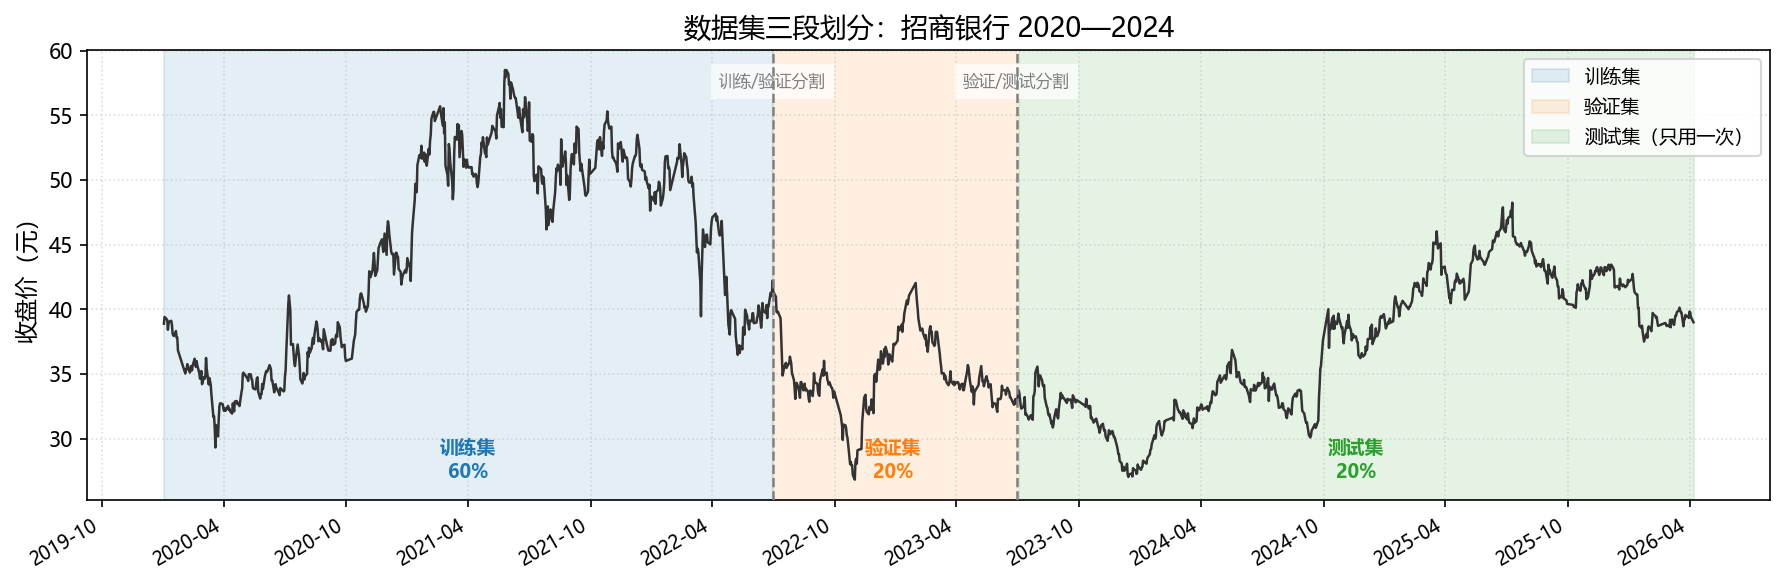

图片已保存：./figs/fig_eval_01_data_split.png


In [2]:
# ------------------------------------------------------------------
# 三段数据集划分：训练 / 验证 / 测试
# ------------------------------------------------------------------
TRAIN_END = '2022-06-30'
VALID_END = '2023-06-30'
# 测试集：2023-07-01 至数据末尾

price = price_cmsb.copy()

train = price[:TRAIN_END]
valid = price[TRAIN_END:VALID_END].iloc[1:]  # 避免重复端点
test  = price[VALID_END:].iloc[1:]

print(f'训练集：{train.index[0].date()} — {train.index[-1].date()}，{len(train)} 日')
print(f'验证集：{valid.index[0].date()} — {valid.index[-1].date()}，{len(valid)} 日')
print(f'测试集：{test.index[0].date()}  — {test.index[-1].date()}，{len(test)} 日')

fig, ax = plt.subplots(figsize=(12, 4))

# 背景色块标注三段
ax.axvspan(train.index[0], train.index[-1], alpha=0.12, color='#1f77b4', label='训练集')
ax.axvspan(valid.index[0], valid.index[-1], alpha=0.12, color='#ff7f0e', label='验证集')
ax.axvspan(test.index[0],  test.index[-1],  alpha=0.12, color='#2ca02c', label='测试集（只用一次）')

# 价格走势
ax.plot(price, color='#333', lw=1.2, zorder=3)

# 分隔竖线
for dt, label in [(TRAIN_END, '训练/验证分割'), (VALID_END, '验证/测试分割')]:
    ax.axvline(pd.Timestamp(dt), color='gray', lw=1.2, ls='--', zorder=4)
    ax.text(pd.Timestamp(dt), ax.get_ylim()[1]*0.97, label,
            ha='center', va='top', fontsize=8, color='gray',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# 标注各段样本量
for seg, color, label in [(train,'#1f77b4','训练集\n60%'),
                           (valid,'#ff7f0e','验证集\n20%'),
                           (test, '#2ca02c','测试集\n20%')]:
    mid = seg.index[len(seg)//2]
    ax.text(mid, price.min()*0.99, label, ha='center', va='bottom',
            fontsize=9, color=color, fontweight='bold')

ax.set_ylabel('收盘价（元）', fontsize=11)
ax.set_title('数据集三段划分：招商银行 2020—2024', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(linestyle=':', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('./figs/fig_eval_01_data_split.png')
plt.show()
print('图片已保存：./figs/fig_eval_01_data_split.png')

## 第1节（续）　Walk-Forward 检验

生成图：`fig_eval_02_walkforward.png`

In [3]:
# ------------------------------------------------------------------
# Walk-Forward 检验实现
# ------------------------------------------------------------------
IS_WINDOW  = 252   # 训练窗口（约1年）
OOS_WINDOW = 63    # 样本外窗口（约3个月）
N1_GRID    = [5, 10, 15, 20]
N2_GRID    = [30, 60, 90, 120]

price = price_cmsb.copy()
price_arr = price.values

wf_records  = []   # 记录每次滚动的参数和绩效
oos_navs    = []   # 样本外净值片段

start = IS_WINDOW
while start + OOS_WINDOW <= len(price):
    # 训练段：[start-IS_WINDOW, start)
    train_price = price.iloc[start - IS_WINDOW: start]
    # 样本外段：[start, start+OOS_WINDOW)
    oos_price   = price.iloc[start: start + OOS_WINDOW]

    # 在训练集上遍历参数网格
    best_sharpe, best_n1, best_n2 = -np.inf, 10, 60
    for n1 in N1_GRID:
        for n2 in N2_GRID:
            if n1 >= n2:
                continue
            nav_is, _ = ma_strategy_nav(train_price, n1, n2)
            ret_is = nav_is.pct_change().dropna()
            if len(ret_is) < 20:
                continue
            sh = (ret_is.mean() * TRADING_DAYS - RF_ANNUAL) / (ret_is.std() * np.sqrt(TRADING_DAYS) + 1e-8)
            if sh > best_sharpe:
                best_sharpe, best_n1, best_n2 = sh, n1, n2

    # 用最优参数在样本外运行
    # 注意：样本外段的均线需要用训练段末尾的价格「预热」
    warm_price = pd.concat([train_price.iloc[-best_n2:], oos_price])
    nav_warm, _ = ma_strategy_nav(warm_price, best_n1, best_n2)
    nav_oos = nav_warm.iloc[-len(oos_price):]
    # 标准化起点为 1
    nav_oos = nav_oos / nav_oos.iloc[0]
    ret_oos = nav_oos.pct_change().dropna()
    oos_sh  = (ret_oos.mean() * TRADING_DAYS - RF_ANNUAL) / (ret_oos.std() * np.sqrt(TRADING_DAYS) + 1e-8)

    wf_records.append({
        '起始日期':    price.index[start].date(),
        '最优N1':      best_n1,
        '最优N2':      best_n2,
        'IS夏普':      round(best_sharpe, 3),
        'OOS夏普':     round(oos_sh, 3),
    })
    oos_navs.append(nav_oos)
    start += OOS_WINDOW  # 向前滑动

wf_df = pd.DataFrame(wf_records)
print('=== Walk-Forward 检验结果 ===')
print(wf_df.to_string(index=False))

# 拼接所有 OOS 净值片段（链式相乘）
combined_nav = []
cumulative   = 1.0
for nav_seg in oos_navs:
    seg = nav_seg * cumulative
    combined_nav.append(seg)
    cumulative = seg.iloc[-1]
oos_nav_full = pd.concat(combined_nav)

print(f'\nWalk-Forward OOS 总收益率：{(oos_nav_full.iloc[-1]-1)*100:.1f}%')
m = calc_metrics(oos_nav_full)
print(f'OOS 夏普比率：{m["夏普比率"]}，OOS 最大回撤：{m["最大回撤(%)"]}')

=== Walk-Forward 检验结果 ===
      起始日期  最优N1  最优N2   IS夏普        OOS夏普
2021-01-15    20    90  1.535        0.506
2021-04-22     5   120  1.647       -0.526
2021-07-26     5    60  1.105       -0.556
2021-11-01    10    30  0.210       -2.516
2022-01-28    10    30 -0.358       -2.239
2022-05-11    15    60 -1.134       -3.835
2022-08-09    20    90 -1.490 -2000000.000
2022-11-14     5    60 -1.014        1.918
2023-02-17     5    60  0.539        0.388
2023-05-23     5    60  0.807       -3.637
2023-08-22     5    60  0.215       -1.260
2023-11-27    20    30 -1.001        2.883
2024-03-04    10   120  0.059        1.530
2024-06-06    10   120  0.813       -1.092
2024-09-04    15    60  0.832        0.788
2024-12-11    15    60  0.554        3.479
2025-03-19    15    60  1.189       -1.198
2025-06-23     5   120  1.495       -1.444
2025-09-18    15    60  0.796       -1.481
2025-12-24    15    30  0.436        1.017

Walk-Forward OOS 总收益率：-11.6%
OOS 夏普比率：-0.141，OOS 最大回撤：-42.21


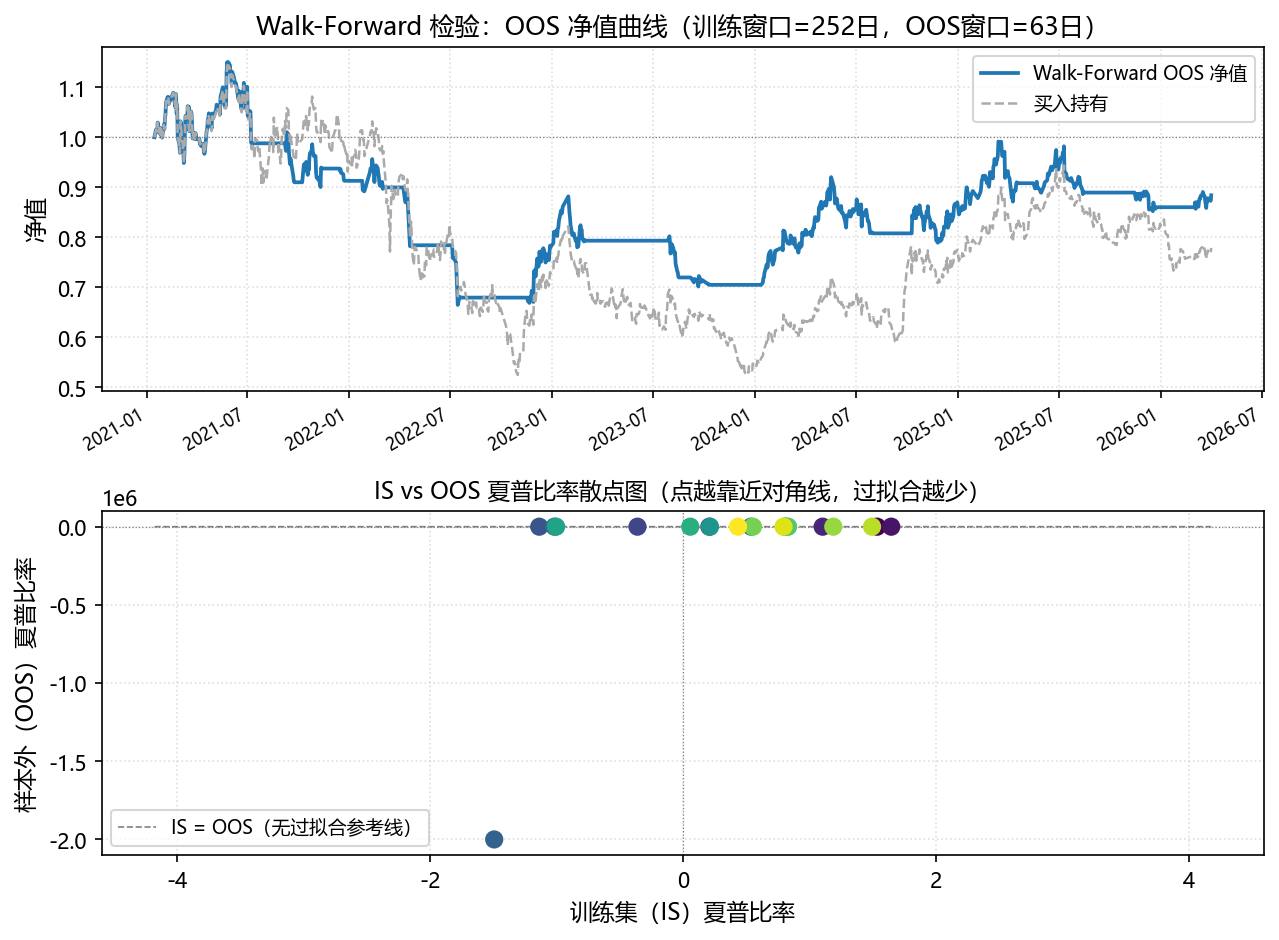

图片已保存：./figs/fig_eval_02_walkforward.png


In [5]:
# 绘制 Walk-Forward 检验图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=False)
fig.subplots_adjust(hspace=0.35)

# 子图1：OOS 净值 vs 买入持有
bnh = price[oos_nav_full.index] / price[oos_nav_full.index[0]]
ax1.plot(oos_nav_full.index, oos_nav_full, color='#1f77b4', lw=1.8,
         label='Walk-Forward OOS 净值')
ax1.plot(bnh.index, bnh, color='#aaa', lw=1.2, ls='--', label='买入持有')
ax1.axhline(1, color='gray', lw=0.6, ls=':')
ax1.set_ylabel('净值', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_title(f'Walk-Forward 检验：OOS 净值曲线（训练窗口={IS_WINDOW}日，OOS窗口={OOS_WINDOW}日）',
              fontsize=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

# 子图2：IS 夏普 vs OOS 夏普的比较（散点图）
ax2.scatter(wf_df['IS夏普'], wf_df['OOS夏普'],
            c=range(len(wf_df)), cmap='viridis', s=60, zorder=3)
xlim = max(abs(wf_df['IS夏普'].max()), abs(wf_df['OOS夏普'].max())) * 1.2
ax2.plot([-xlim, xlim], [-xlim, xlim], color='gray', lw=0.8, ls='--',
         label='IS = OOS（无过拟合参考线）')
ax2.axhline(0, color='gray', lw=0.6, ls=':')
ax2.axvline(0, color='gray', lw=0.6, ls=':')
ax2.set_xlabel('训练集（IS）夏普比率', fontsize=11)
ax2.set_ylabel('样本外（OOS）夏普比率', fontsize=11)
ax2.set_title('IS vs OOS 夏普比率散点图（点越靠近对角线，过拟合越少）', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(linestyle=':', alpha=0.4)

plt.savefig('./figs/fig_eval_02_walkforward.png')
plt.show()
print('图片已保存：./figs/fig_eval_02_walkforward.png')

## 第2节　月度收益热力图

生成图：`fig_eval_03_monthly_heatmap.png`

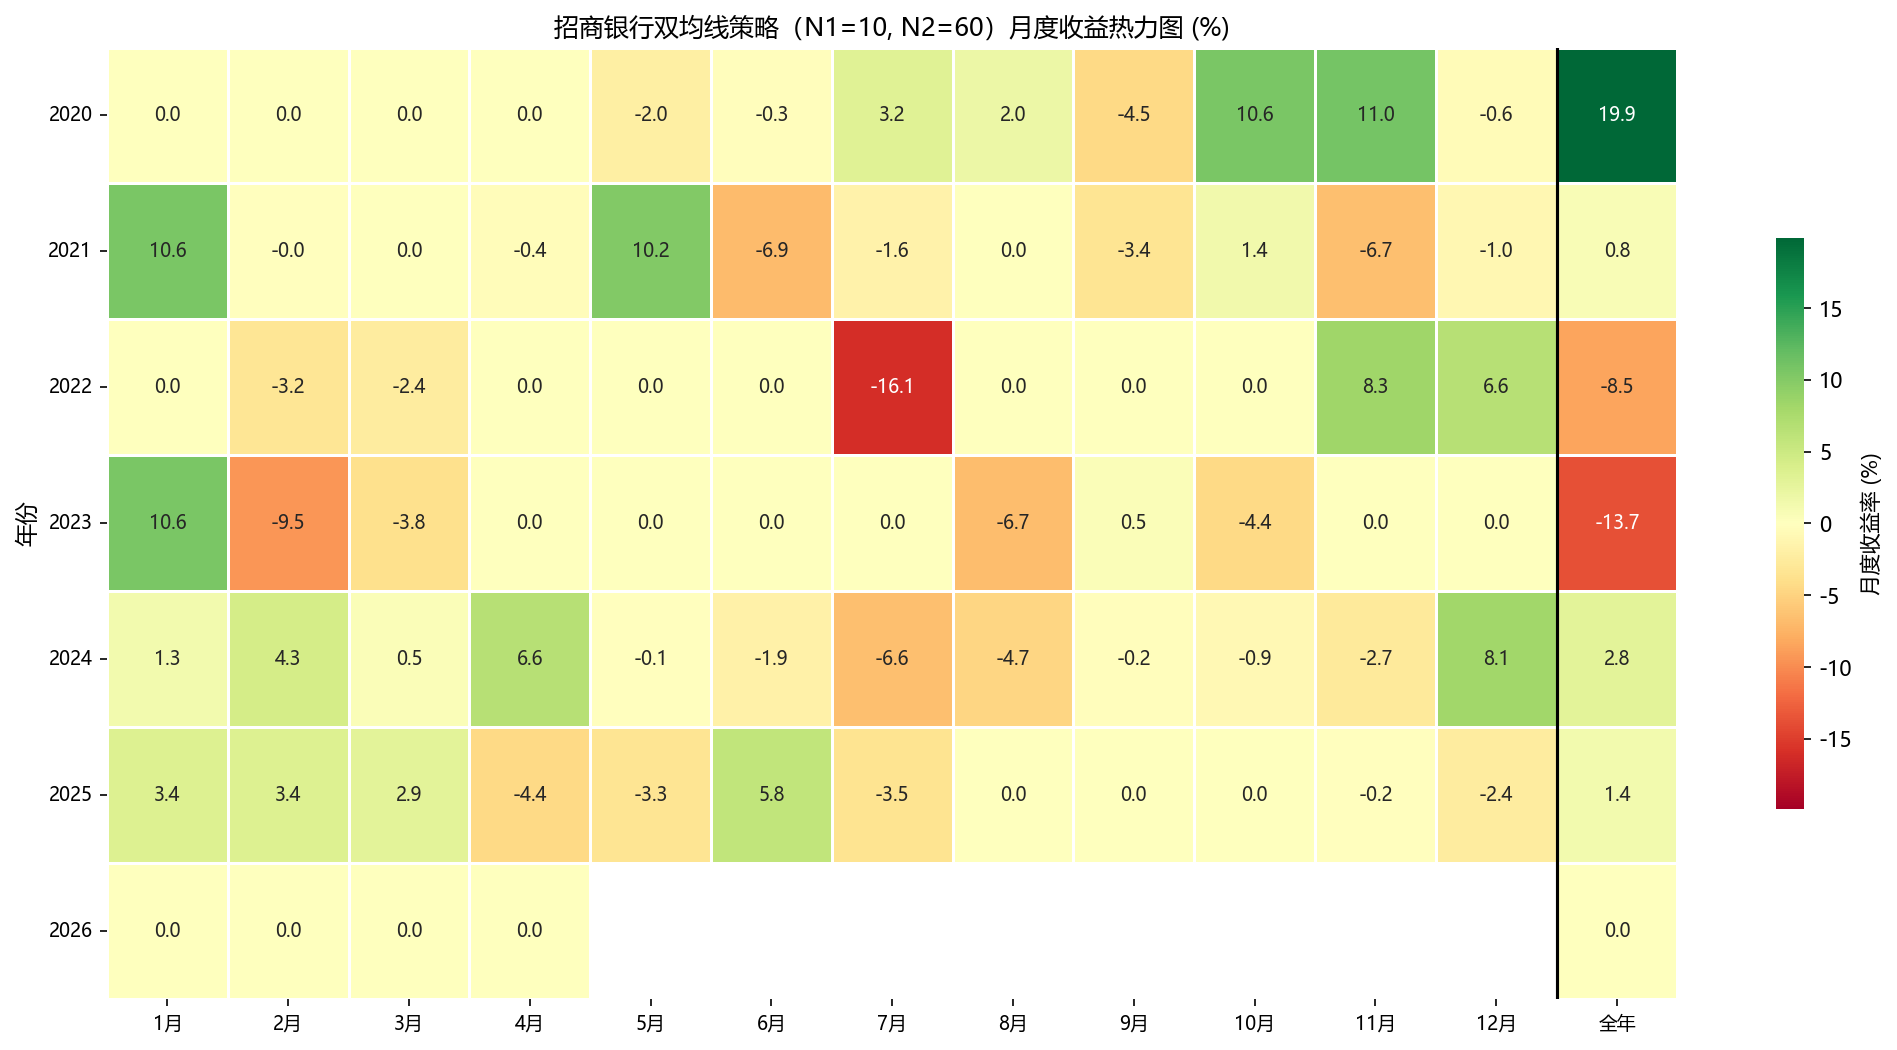

图片已保存：./figs/fig_eval_03_monthly_heatmap.png


In [6]:
# ------------------------------------------------------------------
# 月度收益热力图（招商银行双均线策略，N1=10, N2=60）
# ------------------------------------------------------------------
nav_main, _ = ma_strategy_nav(price_cmsb, n1=10, n2=60)
daily_ret   = nav_main.pct_change().dropna()

# 聚合为月度收益率
monthly_ret = daily_ret.resample('ME').apply(lambda x: (1+x).prod() - 1)

# 转换为 年×月 的矩阵
monthly_df = monthly_ret.to_frame('收益率')
monthly_df['年份'] = monthly_df.index.year
monthly_df['月份'] = monthly_df.index.month
heat_matrix = monthly_df.pivot(index='年份', columns='月份', values='收益率') * 100

# 添加年度列
annual_ret = daily_ret.resample('YE').apply(lambda x: (1+x).prod() - 1) * 100
annual_ret.index = annual_ret.index.year
heat_matrix['全年'] = annual_ret

month_labels = ['1月','2月','3月','4月','5月','6月',
                '7月','8月','9月','10月','11月','12月','全年']
heat_matrix.columns = month_labels[:len(heat_matrix.columns)]

fig, ax = plt.subplots(figsize=(14, len(heat_matrix)*0.8 + 1.5))

# 颜色范围以最大绝对值为基准（正负对称）
vmax = max(abs(heat_matrix.values[np.isfinite(heat_matrix.values)]).max(), 1)

sns.heatmap(heat_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9},
            ax=ax, cbar_kws={'label': '月度收益率 (%)', 'shrink': 0.6})

ax.set_title('招商银行双均线策略（N1=10, N2=60）月度收益热力图 (%)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('年份', fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)

# 「全年」列用竖线分隔
ax.axvline(len(heat_matrix.columns)-1, color='black', lw=1.5)

plt.tight_layout()
plt.savefig('./figs/fig_eval_03_monthly_heatmap.png')
plt.show()
print('图片已保存：./figs/fig_eval_03_monthly_heatmap.png')

## 第3节　Brinson 归因分析

生成图：`fig_eval_04_brinson.png`

In [7]:
# ------------------------------------------------------------------
# Brinson 归因模型（模拟数据演示）
# ------------------------------------------------------------------
brinson_data = pd.DataFrame({
    '行业':      ['银行', '汽车', '科技', '消费', '医药'],
    '组合权重':  [0.40,   0.15,   0.25,   0.10,   0.10],
    '基准权重':  [0.30,   0.20,   0.25,   0.15,   0.10],
    '组合收益率':[0.08,   0.12,   0.22,   0.05,   0.15],
    '基准收益率':[0.05,   0.10,   0.18,   0.07,   0.12],
})

# 基准总收益
R_b = (brinson_data['基准权重'] * brinson_data['基准收益率']).sum()
R_p = (brinson_data['组合权重'] * brinson_data['组合收益率']).sum()

# 配置效应：(组合权重 - 基准权重) × 基准收益率
# 注：严格 Brinson 模型用 (基准行业收益 - 基准总收益)，此处用简化版
brinson_data['配置效应(AA)'] = (
    (brinson_data['组合权重'] - brinson_data['基准权重'])
    * (brinson_data['基准收益率'] - R_b)
)
# 选股效应：基准权重 × (组合行业收益 - 基准行业收益)
brinson_data['选股效应(SS)'] = (
    brinson_data['基准权重']
    * (brinson_data['组合收益率'] - brinson_data['基准收益率'])
)
# 交互效应
brinson_data['交互效应(IA)'] = (
    (brinson_data['组合权重'] - brinson_data['基准权重'])
    * (brinson_data['组合收益率'] - brinson_data['基准收益率'])
)
brinson_data['合计'] = (brinson_data['配置效应(AA)'] +
                        brinson_data['选股效应(SS)'] +
                        brinson_data['交互效应(IA)'])

print(f'组合总收益率：{R_p*100:.2f}%，基准总收益率：{R_b*100:.2f}%')
print(f'总超额收益：{(R_p-R_b)*100:.2f}%')
print(f'\nAA合计：{brinson_data["配置效应(AA)"].sum()*100:.2f}%')
print(f'SS合计：{brinson_data["选股效应(SS)"].sum()*100:.2f}%')
print(f'IA合计：{brinson_data["交互效应(IA)"].sum()*100:.2f}%')
print(f'三项合计：{brinson_data["合计"].sum()*100:.2f}%  （应≈总超额收益）')

display_cols = ['行业','配置效应(AA)','选股效应(SS)','交互效应(IA)','合计']
print('\n=== Brinson 归因汇总表 ===')
print((brinson_data[display_cols].set_index('行业') * 100).round(3).to_string())

组合总收益率：12.50%，基准总收益率：10.25%
总超额收益：2.25%

AA合计：-0.35%
SS合计：2.30%
IA合计：0.30%
三项合计：2.25%  （应≈总超额收益）

=== Brinson 归因汇总表 ===
    配置效应(AA)  选股效应(SS)  交互效应(IA)     合计
行业                                     
银行    -0.525       0.9       0.3  0.675
汽车     0.012       0.4      -0.1  0.312
科技     0.000       1.0       0.0  1.000
消费     0.162      -0.3       0.1 -0.038
医药     0.000       0.3       0.0  0.300


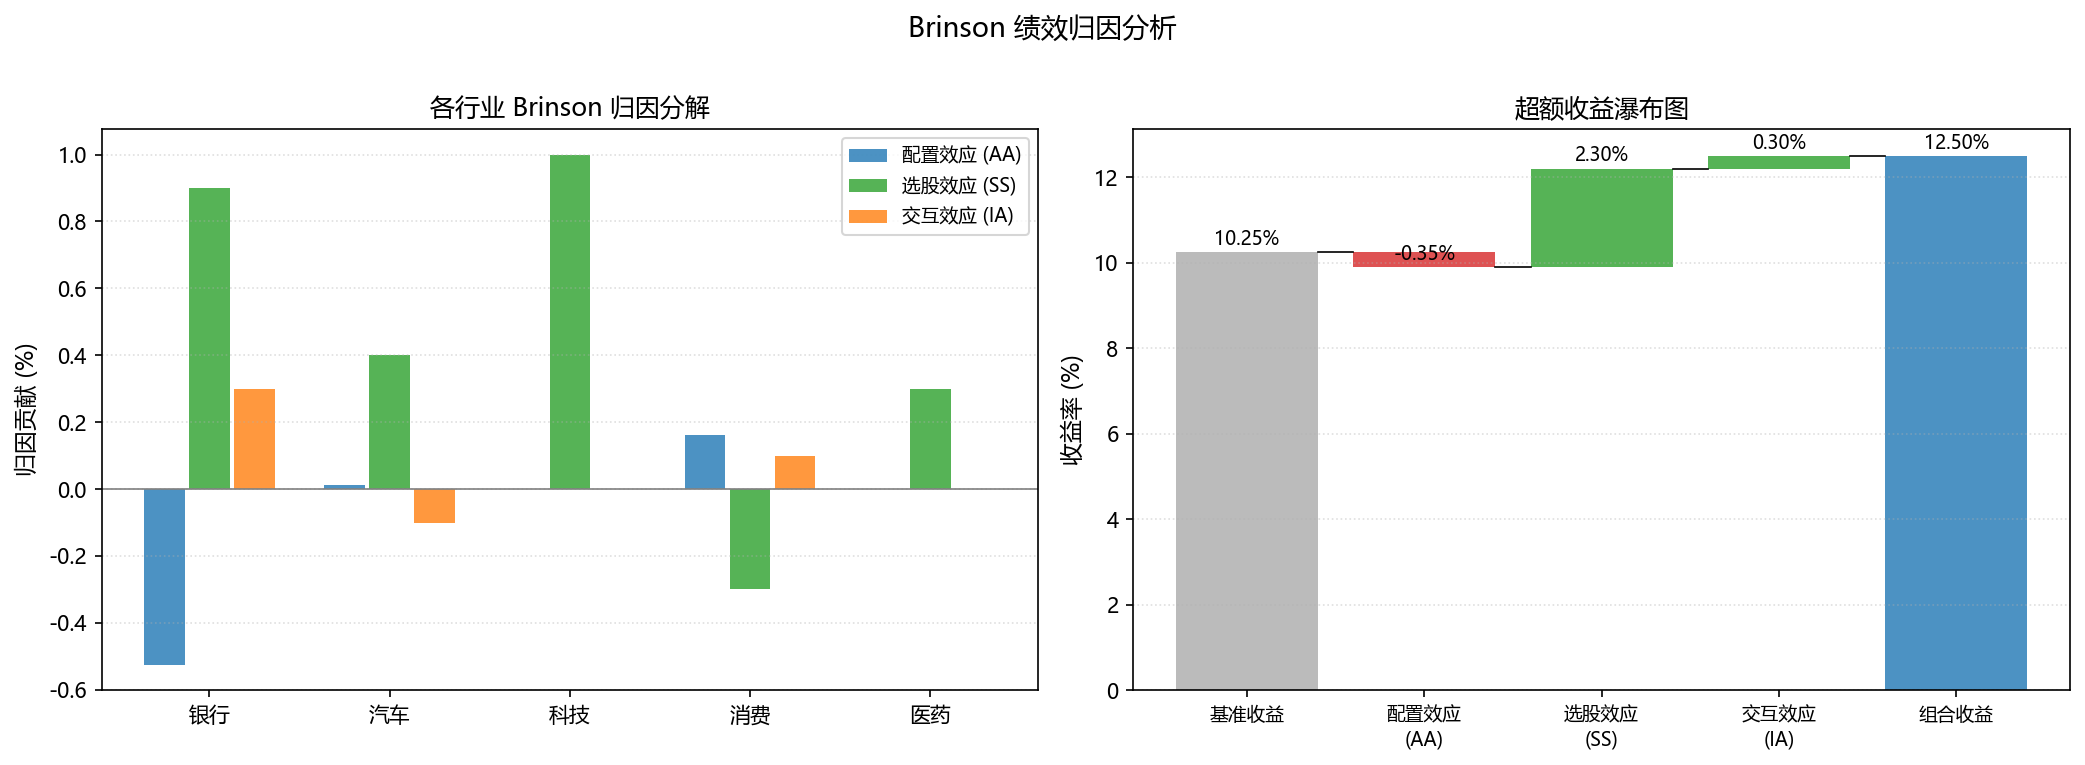

图片已保存：./figs/fig_eval_04_brinson.png


In [8]:
# 绘图：分组柱状图 + 瀑布图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各行业 AA/SS/IA 分组柱状图
industries = brinson_data['行业'].tolist()
x = np.arange(len(industries))
w = 0.25
colors_bar = ['#1f77b4', '#d62728', '#2ca02c']

for i, (col, label, color) in enumerate([
    ('配置效应(AA)', '配置效应 (AA)', '#1f77b4'),
    ('选股效应(SS)', '选股效应 (SS)', '#2ca02c'),
    ('交互效应(IA)', '交互效应 (IA)', '#ff7f0e'),
]):
    vals = brinson_data[col].values * 100
    bars = ax1.bar(x + (i-1)*w, vals, w*0.9, label=label, color=color, alpha=0.8)

ax1.axhline(0, color='gray', lw=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(industries, fontsize=10)
ax1.set_ylabel('归因贡献 (%)', fontsize=11)
ax1.set_title('各行业 Brinson 归因分解', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

# 右图：瀑布图（从基准收益到组合收益）
aa_total = brinson_data['配置效应(AA)'].sum() * 100
ss_total = brinson_data['选股效应(SS)'].sum() * 100
ia_total = brinson_data['交互效应(IA)'].sum() * 100

waterfall_labels = ['基准收益', '配置效应\n(AA)', '选股效应\n(SS)', '交互效应\n(IA)', '组合收益']
base  = R_b * 100
steps = [base, aa_total, ss_total, ia_total]
cumvals = [base, base+aa_total, base+aa_total+ss_total,
           base+aa_total+ss_total+ia_total]
bottoms = [0, base, base+aa_total, base+aa_total+ss_total]

wf_colors = ['#aaa', '#2ca02c' if aa_total>=0 else '#d62728',
             '#2ca02c' if ss_total>=0 else '#d62728',
             '#2ca02c' if ia_total>=0 else '#d62728', '#1f77b4']

# 基准和组合收益从0开始
ax2.bar([0], [base], color='#aaa', alpha=0.8)
ax2.bar([1, 2, 3], [aa_total, ss_total, ia_total],
        bottom=[base, base+aa_total, base+aa_total+ss_total],
        color=['#2ca02c' if v>=0 else '#d62728' for v in [aa_total,ss_total,ia_total]],
        alpha=0.8)
ax2.bar([4], [R_p*100], color='#1f77b4', alpha=0.8)

# 连接线
running = base
for i, step in enumerate([aa_total, ss_total, ia_total]):
    ax2.plot([i+0.4, i+0.6], [running, running], 'k-', lw=0.8)
    running += step
ax2.plot([3.4, 3.6], [running, running], 'k-', lw=0.8)

# 数值标注
for i, (val, bot) in enumerate([(base,0),(aa_total,base),
                                  (ss_total,base+aa_total),
                                  (ia_total,base+aa_total+ss_total),
                                  (R_p*100,0)]):
    ax2.text(i, bot + val + 0.05, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(range(5))
ax2.set_xticklabels(waterfall_labels, fontsize=9)
ax2.set_ylabel('收益率 (%)', fontsize=11)
ax2.set_title('超额收益瀑布图', fontsize=12)
ax2.grid(axis='y', linestyle=':', alpha=0.4)

plt.suptitle('Brinson 绩效归因分析', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figs/fig_eval_04_brinson.png')
plt.show()
print('图片已保存：./figs/fig_eval_04_brinson.png')

## 第3节（续）　多因子归因

生成图：`fig_eval_05_factor_attr.png`

In [9]:
# ------------------------------------------------------------------
# 因子归因：CAPM + 两因子回归
# ------------------------------------------------------------------
nav_main, _ = ma_strategy_nav(price_cmsb, n1=10, n2=60)
strat_ret   = nav_main.pct_change().dropna()
mkt_ret     = price_idx.pct_change().dropna()

# 对齐日期
common = strat_ret.index.intersection(mkt_ret.index)
sr = strat_ret[common]
mr = mkt_ret[common]

# 超额收益
sr_exc = sr - RF_DAILY
mr_exc = mr - RF_DAILY

# SMB 代理：随机生成（实际应从 CSMAR 获取）
# 在此用白噪声加少量趋势模拟，演示回归结构
np.random.seed(0)
smb = pd.Series(np.random.normal(0.0002, 0.008, len(common)),
                index=common, name='SMB代理')

# 模型1：CAPM（单因子）
X1 = sm.add_constant(mr_exc)
m1 = sm.OLS(sr_exc, X1).fit()
print('=== 模型1：CAPM ===')
print(m1.summary().tables[1])

# 模型2：两因子（市场 + SMB）
X2 = sm.add_constant(pd.DataFrame({'MKT': mr_exc, 'SMB': smb}))
m2 = sm.OLS(sr_exc, X2).fit()
print('\n=== 模型2：两因子（市场 + SMB代理）===')
print(m2.summary().tables[1])

# 归因贡献表
factor_annual_means = {'MKT': mr_exc.mean()*TRADING_DAYS,
                       'SMB': smb.mean()*TRADING_DAYS}
print('\n=== 因子归因贡献（年化）===')
for fname, beta in zip(['MKT','SMB'], m2.params[1:]):
    contrib = beta * factor_annual_means[fname]
    print(f'{fname}：β={beta:.4f}，年化因子收益={factor_annual_means[fname]*100:.2f}%，'
          f'贡献={contrib*100:.2f}%')
print(f'纯Alpha（截距年化）：{m2.params[0]*TRADING_DAYS*100:.2f}%')
print(f'调整R²：{m2.rsquared_adj:.4f}')

=== 模型1：CAPM ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.299e-05      0.000     -0.079      0.937      -0.001       0.001
收盘价            0.4182      0.024     17.135      0.000       0.370       0.466

=== 模型2：两因子（市场 + SMB代理）===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.214e-05      0.000     -0.077      0.939      -0.001       0.001
MKT            0.4184      0.024     17.142      0.000       0.371       0.466
SMB           -0.0369      0.037     -1.000      0.318      -0.109       0.036

=== 因子归因贡献（年化）===
MKT：β=0.4184，年化因子收益=0.89%，贡献=0.37%
SMB：β=-0.0369，年化因子收益=0.59%，贡献=-0.02%
纯Alpha（截距年化）：-0.56%
调整R²：0.1621


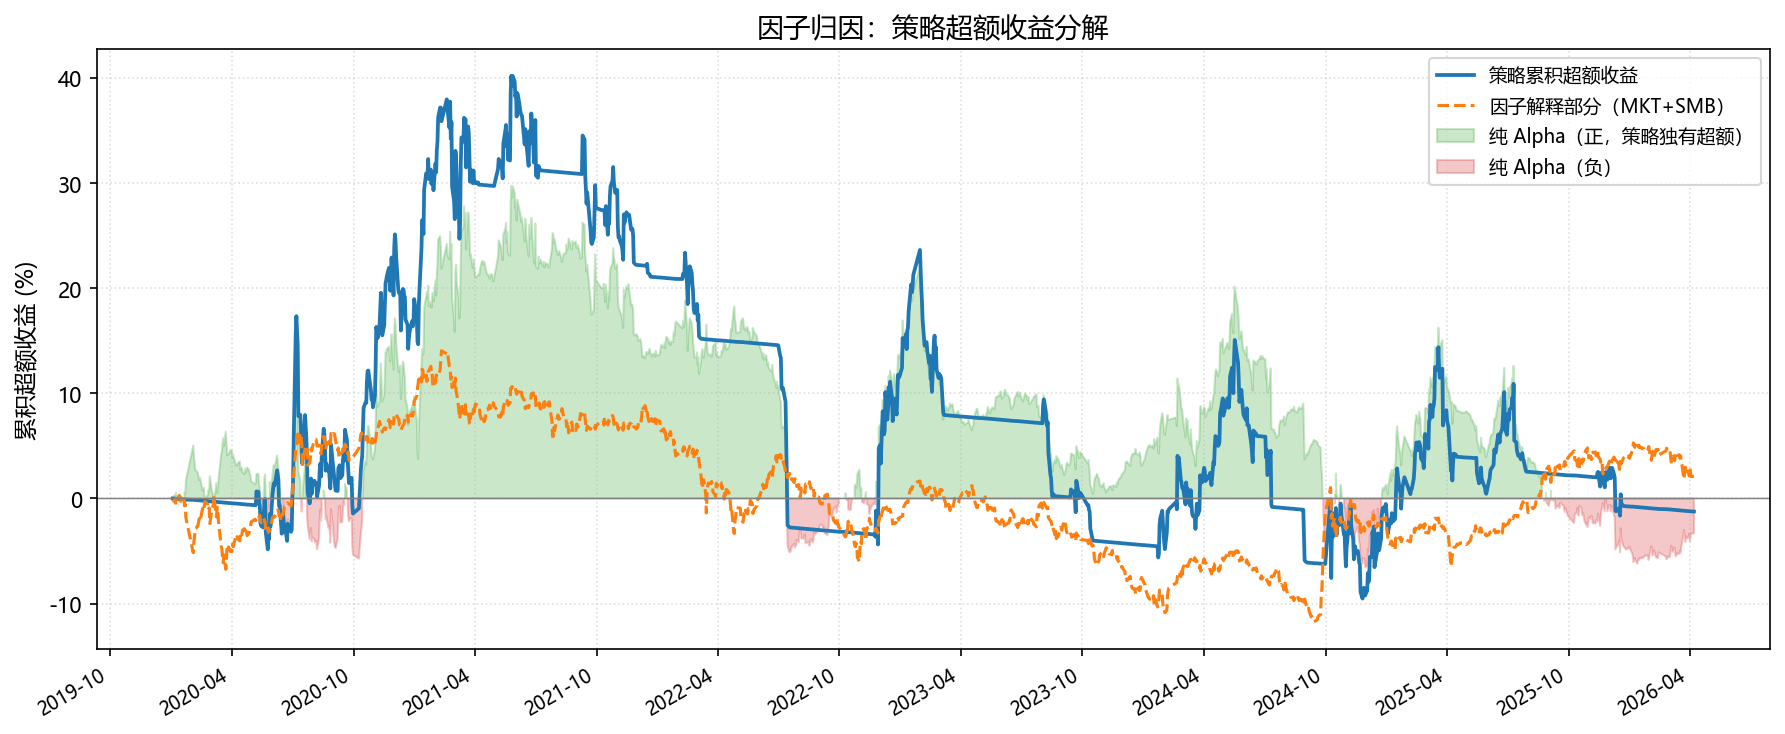

图片已保存：./figs/fig_eval_05_factor_attr.png


In [10]:
# 绘制因子归因累积图
# 策略累积超额收益 vs 各因子解释部分 vs 纯 Alpha
mkt_contrib_daily  = m2.params[1] * mr_exc   # 市场因子每日贡献
smb_contrib_daily  = m2.params[2] * smb       # SMB 因子每日贡献
alpha_daily        = m2.params[0]             # 常数（日度）
alpha_series       = pd.Series(alpha_daily, index=common)
factor_total_daily = mkt_contrib_daily + smb_contrib_daily

cum_strat   = sr_exc.cumsum() * 100
cum_factor  = factor_total_daily.cumsum() * 100
cum_alpha   = (sr_exc - factor_total_daily).cumsum() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_strat,  lw=1.8, color='#1f77b4', label='策略累积超额收益')
ax.plot(cum_factor, lw=1.5, color='#ff7f0e', ls='--', label='因子解释部分（MKT+SMB）')
ax.fill_between(cum_alpha.index, cum_alpha, 0,
                where=(cum_alpha >= 0), alpha=0.25, color='#2ca02c',
                label='纯 Alpha（正，策略独有超额）')
ax.fill_between(cum_alpha.index, cum_alpha, 0,
                where=(cum_alpha < 0), alpha=0.25, color='#d62728',
                label='纯 Alpha（负）')
ax.axhline(0, color='gray', lw=0.7)
ax.set_ylabel('累积超额收益 (%)', fontsize=11)
ax.set_title('因子归因：策略超额收益分解', fontsize=13)
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('./figs/fig_eval_05_factor_attr.png')
plt.show()
print('图片已保存：./figs/fig_eval_05_factor_attr.png')

## 第4节　风险管理

生成图：`fig_eval_06_vol_target.png`、`fig_eval_07_trailing_stop.png`

固定满仓：年化收益=1.8%，波动率=19.5%，MDD=-38.3%，夏普=-0.011
波动率目标：年化收益=2.3%，波动率=10.4%，MDD=-23.6%，夏普=0.026


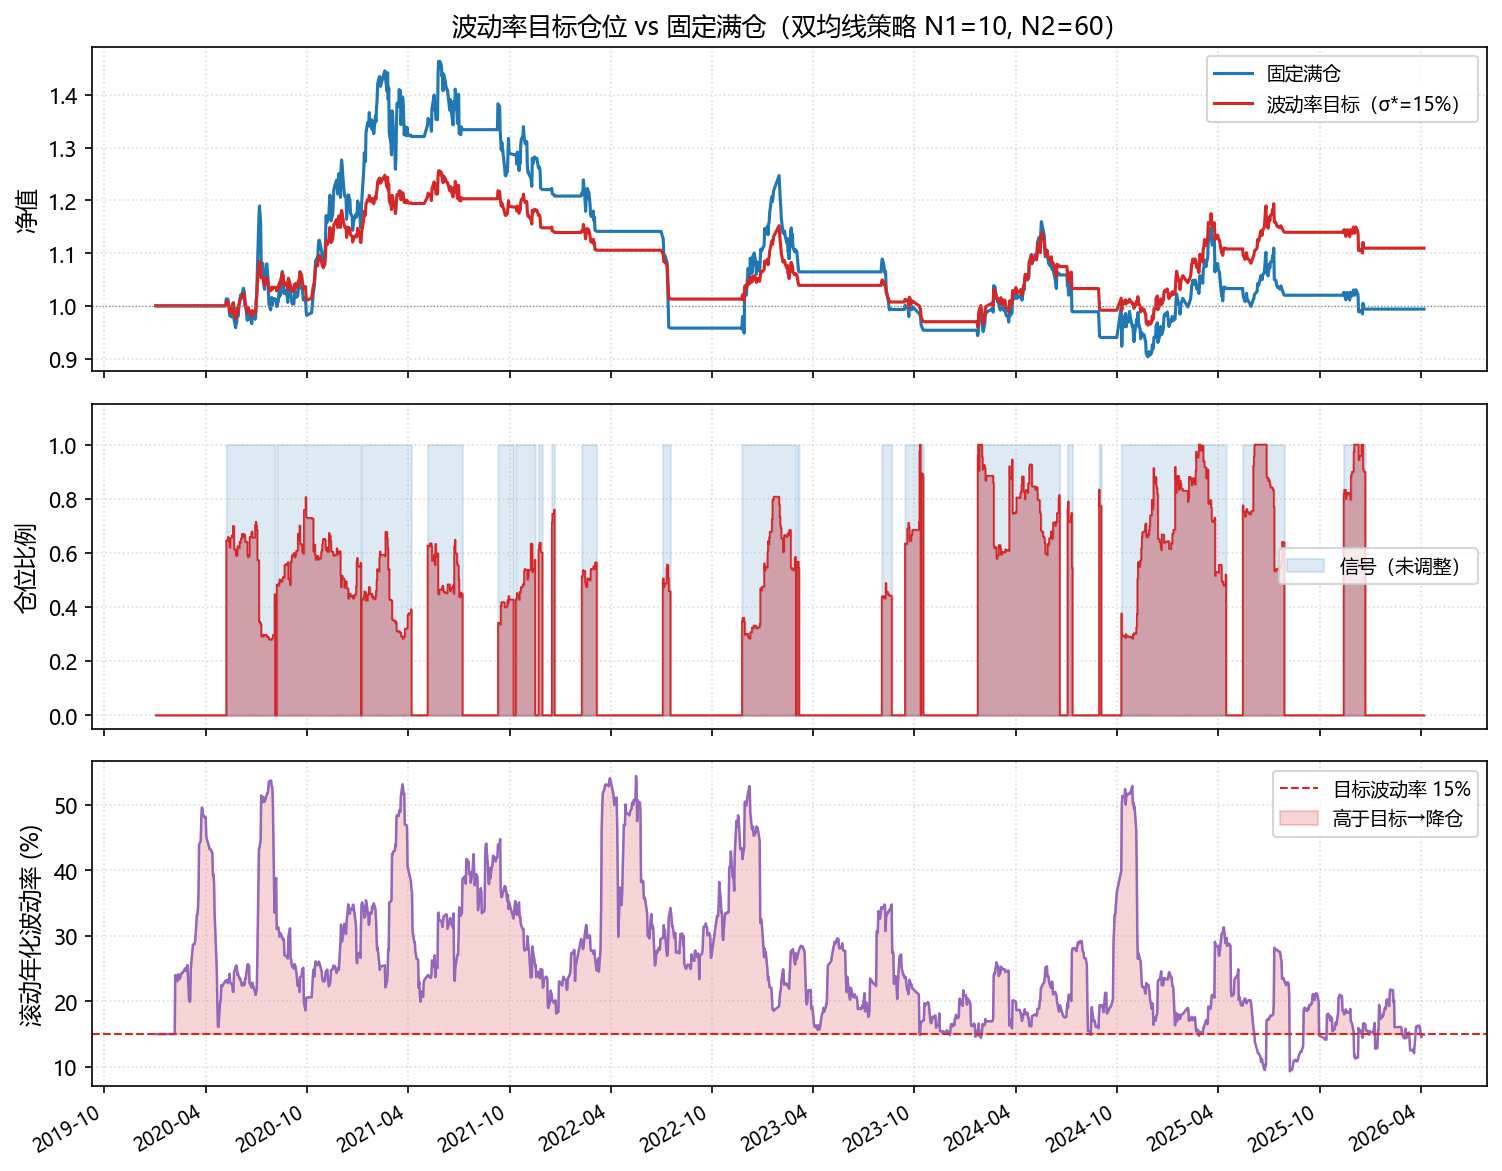

图片已保存：./figs/fig_eval_06_vol_target.png


In [11]:
# ------------------------------------------------------------------
# 波动率目标仓位 vs 固定满仓
# fig_eval_06_vol_target.png
# ------------------------------------------------------------------
VOL_TARGET = 0.15   # 目标年化波动率 15%
VOL_WIN    = 20     # 滚动波动率估计窗口
N1, N2     = 10, 60

price  = price_cmsb.copy()
ret    = price.pct_change().fillna(0)
ma_s   = price.rolling(N1).mean()
ma_l   = price.rolling(N2).mean()
signal = ((ma_s > ma_l).astype(int)).shift(1).fillna(0)  # 信号次日生效

# 滚动年化波动率
rolling_vol = ret.rolling(VOL_WIN).std() * np.sqrt(TRADING_DAYS)
rolling_vol = rolling_vol.replace(0, np.nan).ffill().fillna(VOL_TARGET)

# 波动率目标仓位：min(目标波动率 / 实际波动率, 1.0)
vol_position = (signal * np.minimum(VOL_TARGET / rolling_vol, 1.0)).fillna(0)

# 计算两版本净值
def nav_from_position(price, position, fees=FEES):
    r     = price.pct_change().fillna(0)
    tc    = position.diff().abs().fillna(0) * fees
    pnl   = position * r - tc
    return (1 + pnl).cumprod()

nav_fixed = nav_from_position(price, signal)
nav_vt    = nav_from_position(price, vol_position)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.subplots_adjust(hspace=0.1)

# 子图1：净值对比
ax1.plot(nav_fixed, color='#1f77b4', lw=1.5, label='固定满仓')
ax1.plot(nav_vt,    color='#d62728', lw=1.5, label=f'波动率目标（σ*={VOL_TARGET*100:.0f}%）')
ax1.axhline(1, color='gray', lw=0.6, ls=':')
ax1.set_ylabel('净值', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_title(f'波动率目标仓位 vs 固定满仓（双均线策略 N1={N1}, N2={N2}）', fontsize=12)

# 子图2：动态仓位
ax2.fill_between(vol_position.index, vol_position, 0, alpha=0.4,
                 color='#d62728', step='post')
ax2.plot(vol_position, color='#d62728', lw=0.8, drawstyle='steps-post')
ax2.fill_between(signal.index, signal, 0, alpha=0.15,
                 color='#1f77b4', step='post', label='信号（未调整）')
ax2.set_ylabel('仓位比例', fontsize=11)
ax2.set_ylim(-0.05, 1.15)
ax2.legend(fontsize=9)
ax2.grid(linestyle=':', alpha=0.4)

# 子图3：滚动波动率
ax3.plot(rolling_vol * 100, color='#9467bd', lw=1.2)
ax3.axhline(VOL_TARGET * 100, color='#d62728', lw=1, ls='--',
            label=f'目标波动率 {VOL_TARGET*100:.0f}%')
ax3.fill_between(rolling_vol.index, rolling_vol*100, VOL_TARGET*100,
                 where=(rolling_vol > VOL_TARGET), alpha=0.2, color='#d62728',
                 label='高于目标→降仓')
ax3.set_ylabel('滚动年化波动率 (%)', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(linestyle=':', alpha=0.4)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

# 打印绩效对比
for label, nav in [('固定满仓', nav_fixed), ('波动率目标', nav_vt)]:
    m = calc_metrics(nav)
    print(f'{label}：年化收益={m["年化收益率(%)"]:.1f}%，波动率={m["年化波动率(%)"]:.1f}%，'
          f'MDD={m["最大回撤(%)"]:.1f}%，夏普={m["夏普比率"]}')

plt.savefig('./figs/fig_eval_06_vol_target.png')
plt.show()
print('图片已保存：./figs/fig_eval_06_vol_target.png')

=== 追踪止损对比 ===
A: 无止损（止损触发0次）：年化=1.8%，MDD=-38.3%，夏普=-0.011
B: 10%止损（止损触发7次）：年化=2.0%，MDD=-36.9%，夏普=0.002
C: 15%止损（止损触发2次）：年化=1.6%，MDD=-38.3%，夏普=-0.021


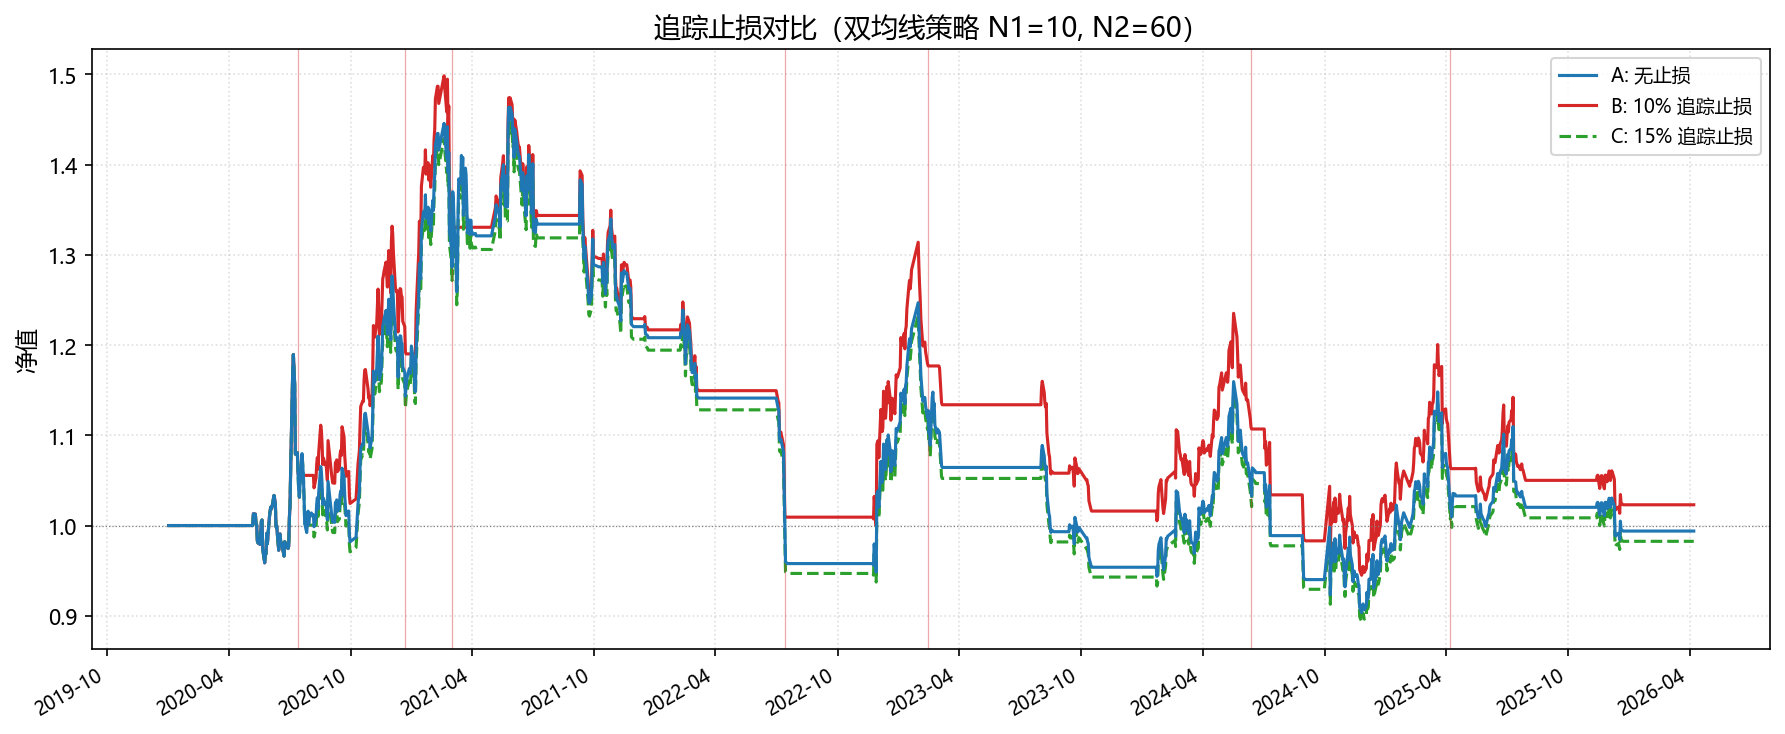

图片已保存：./figs/fig_eval_07_trailing_stop.png


In [12]:
# ------------------------------------------------------------------
# 追踪止损（Trailing Stop）
# fig_eval_07_trailing_stop.png
# ------------------------------------------------------------------
def trailing_stop_nav(price, n1, n2, trail_pct, fees=FEES):
    """带追踪止损的双均线策略。
    trail_pct: 追踪止损幅度（如 0.10 = 10%）。
    返回：净值序列、止损触发日期列表。
    """
    ma_s = price.rolling(n1).mean()
    ma_l = price.rolling(n2).mean()
    gold_cross = (ma_s > ma_l) & (ma_s.shift(1) <= ma_l.shift(1))  # 金叉
    dead_cross = (ma_s < ma_l) & (ma_s.shift(1) >= ma_l.shift(1))  # 死叉

    position    = 0       # 当前持仓状态
    peak_price  = 0.0     # 持仓期间最高价
    positions   = []      # 每日持仓记录
    stop_dates  = []      # 止损触发日期

    for i in range(len(price)):
        p = price.iloc[i]
        if position == 0:
            # 空仓：等待金叉信号
            if gold_cross.iloc[i]:
                position   = 1
                peak_price = p
        else:
            # 持仓：更新追踪最高价
            peak_price = max(peak_price, p)
            # 检查追踪止损
            if p < peak_price * (1 - trail_pct):
                position = 0
                stop_dates.append(price.index[i])
            # 检查死叉信号
            elif dead_cross.iloc[i]:
                position = 0
        positions.append(position)

    pos_series = pd.Series(positions, index=price.index)
    # 次日生效
    pos_shifted = pos_series.shift(1).fillna(0)
    ret    = price.pct_change().fillna(0)
    tc     = pos_shifted.diff().abs().fillna(0) * fees
    pnl    = pos_shifted * ret - tc
    nav    = (1 + pnl).cumprod()
    return nav, stop_dates

nav_A, _          = ma_strategy_nav(price_cmsb, 10, 60)         # 无止损
nav_B, stops_B    = trailing_stop_nav(price_cmsb, 10, 60, 0.10) # 10% 追踪止损
nav_C, stops_C    = trailing_stop_nav(price_cmsb, 10, 60, 0.15) # 15% 追踪止损

print('=== 追踪止损对比 ===')
for label, nav, stops in [
    ('A: 无止损', nav_A, []),
    ('B: 10%止损', nav_B, stops_B),
    ('C: 15%止损', nav_C, stops_C),
]:
    m = calc_metrics(nav)
    print(f'{label}（止损触发{len(stops)}次）：'
          f'年化={m["年化收益率(%)"]:.1f}%，MDD={m["最大回撤(%)"]:.1f}%，夏普={m["夏普比率"]}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(nav_A, color='#1f77b4', lw=1.5, label='A: 无止损', zorder=3)
ax.plot(nav_B, color='#d62728', lw=1.5, label='B: 10% 追踪止损')
ax.plot(nav_C, color='#2ca02c', lw=1.5, ls='--', label='C: 15% 追踪止损')

# 标注止损触发点
for dt in stops_B:
    ax.axvline(dt, color='#d62728', lw=0.6, alpha=0.4)

ax.axhline(1, color='gray', lw=0.6, ls=':')
ax.set_ylabel('净值', fontsize=11)
ax.set_title('追踪止损对比（双均线策略 N1=10, N2=60）', fontsize=13)
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('./figs/fig_eval_07_trailing_stop.png')
plt.show()
print('图片已保存：./figs/fig_eval_07_trailing_stop.png')

## 第5节　quantstats 报告

生成图：`fig_eval_08_rolling_sharpe.png`、`fig_eval_09_drawdowns.png`

In [ ]:
#!pip install quantstats

In [16]:
try:
    import quantstats as qs
    QS_AVAILABLE = True
    print('quantstats 已安装')
except ImportError:
    QS_AVAILABLE = False
    print('quantstats 未安装，请运行：pip install quantstats')

if QS_AVAILABLE:
    nav_qs, _  = ma_strategy_nav(price_cmsb, n1=10, n2=60)
    returns_qs = nav_qs.pct_change().dropna()
    bench_qs   = price_idx.pct_change().dropna()

    # 对齐基准
    common_idx = returns_qs.index.intersection(bench_qs.index)
    returns_qs = returns_qs[common_idx]
    bench_qs   = bench_qs[common_idx]

    # 打印完整指标表
    print('\n=== quantstats 完整绩效指标 ===')
    qs.reports.metrics(returns_qs, benchmark=bench_qs, mode='full')

    # 生成 HTML 报告
    qs.reports.html(returns_qs, benchmark=bench_qs,
                    output='strategy_report.html',
                    title='招商银行双均线策略评估报告')
    print('\nHTML 报告已保存：./strategy_report.html')

    # 单独保存各子图
    qs.plots.rolling_sharpe(
        returns_qs,
        benchmark=bench_qs,
        period=126,
        savefig='./figs/fig_eval_08_rolling_sharpe.png',
        show=False
    )
    plt.close('all')
    print('图片已保存：./figs/fig_eval_08_rolling_sharpe.png')

    qs.plots.drawdowns_periods(
        returns_qs,
        savefig='./figs/fig_eval_09_drawdowns.png',
        show=False
    )
    plt.close('all')
    print('图片已保存：./figs/fig_eval_09_drawdowns.png')

quantstats 已安装

=== quantstats 完整绩效指标 ===

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2020-05-08   2020-05-08
End Period                 2026-04-07   2026-04-07
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       53.0%

Cumulative Return          13.14%       -0.61%
CAGR﹪                     2.19%        -0.11%

Sharpe                     0.21         0.09
Prob. Sharpe Ratio         69.19%       58.92%
Smart Sharpe               0.2          0.09
Sortino                    0.3          0.14
Smart Sortino              0.29         0.13
Sortino/√2                 0.21         0.1
Smart Sortino/√2           0.2          0.09
Omega                      1.04         1.02

Max Drawdown               -45.6%       -38.26%
Ma

## 第6节　综合案例：完整评价流程

生成图：`fig_eval_10_full_evaluation.png`

In [17]:
# ------------------------------------------------------------------
# 完整评价流程：数据划分 → 参数优化 → Walk-Forward → 绩效雷达图
# ------------------------------------------------------------------
price = price_cmsb.copy()
TRAIN_END = '2022-06-30'
VALID_END = '2023-06-30'

price_train = price[:TRAIN_END]
price_valid = price[TRAIN_END:VALID_END].iloc[1:]
price_test  = price[VALID_END:].iloc[1:]

# ---- 步骤2：训练集参数搜索 ----
N1_GRID = [5, 10, 15, 20]
N2_GRID = [30, 60, 90, 120]

sharpe_grid = pd.DataFrame(index=N1_GRID, columns=N2_GRID, dtype=float)
for n1 in N1_GRID:
    for n2 in N2_GRID:
        if n1 >= n2:
            continue
        nav_tr, _ = ma_strategy_nav(price_train, n1, n2)
        r = nav_tr.pct_change().dropna()
        if len(r) < 20:
            continue
        sh = (r.mean()*TRADING_DAYS - RF_ANNUAL) / (r.std()*np.sqrt(TRADING_DAYS) + 1e-8)
        sharpe_grid.loc[n1, n2] = round(sh, 3)

best_idx = sharpe_grid.stack().idxmax()
BEST_N1, BEST_N2 = best_idx
IS_BEST_SHARPE   = sharpe_grid.loc[BEST_N1, BEST_N2]
print(f'最优参数：N1={BEST_N1}, N2={BEST_N2}，训练集夏普={IS_BEST_SHARPE:.3f}')

# ---- 步骤3：验证集 ----
nav_valid, _ = ma_strategy_nav(price_valid, BEST_N1, BEST_N2)
r_valid = nav_valid.pct_change().dropna()
valid_sharpe = (r_valid.mean()*TRADING_DAYS - RF_ANNUAL) / (r_valid.std()*np.sqrt(TRADING_DAYS) + 1e-8)
print(f'验证集夏普：{valid_sharpe:.3f}（IS/OOS 差异：{(IS_BEST_SHARPE - valid_sharpe):.3f}）')

# ---- 步骤4：测试集最终评价 ----
nav_test,  _ = ma_strategy_nav(price_test,  BEST_N1, BEST_N2)
nav_bnh_test = price_test / price_test.iloc[0]
nav_idx_test = price_idx.reindex(price_test.index).ffill()
nav_idx_test = nav_idx_test / nav_idx_test.iloc[0]

m_test   = calc_metrics(nav_test,  benchmark_nav=nav_idx_test)
m_bnh    = calc_metrics(nav_bnh_test)
print(f'\n=== 测试集绩效（N1={BEST_N1}, N2={BEST_N2}）===')
for k, v in m_test.items():
    print(f'  {k}: {v}')

最优参数：N1=20, N2=90，训练集夏普=0.530
验证集夏普：-0.475（IS/OOS 差异：1.005）

=== 测试集绩效（N1=20, N2=90）===
  年化收益率(%): 5.59
  年化波动率(%): 14.97
  最大回撤(%): -17.41
  夏普比率: 0.24
  索提诺比率: 0.292
  卡玛比率: 0.321
  日CVaR95%(%): 2.406
  负收益月份占比: 23.5%
  年化超额收益(%): -0.9
  信息比率: -0.046
  跟踪误差(%): 19.74
  Beta: 0.229


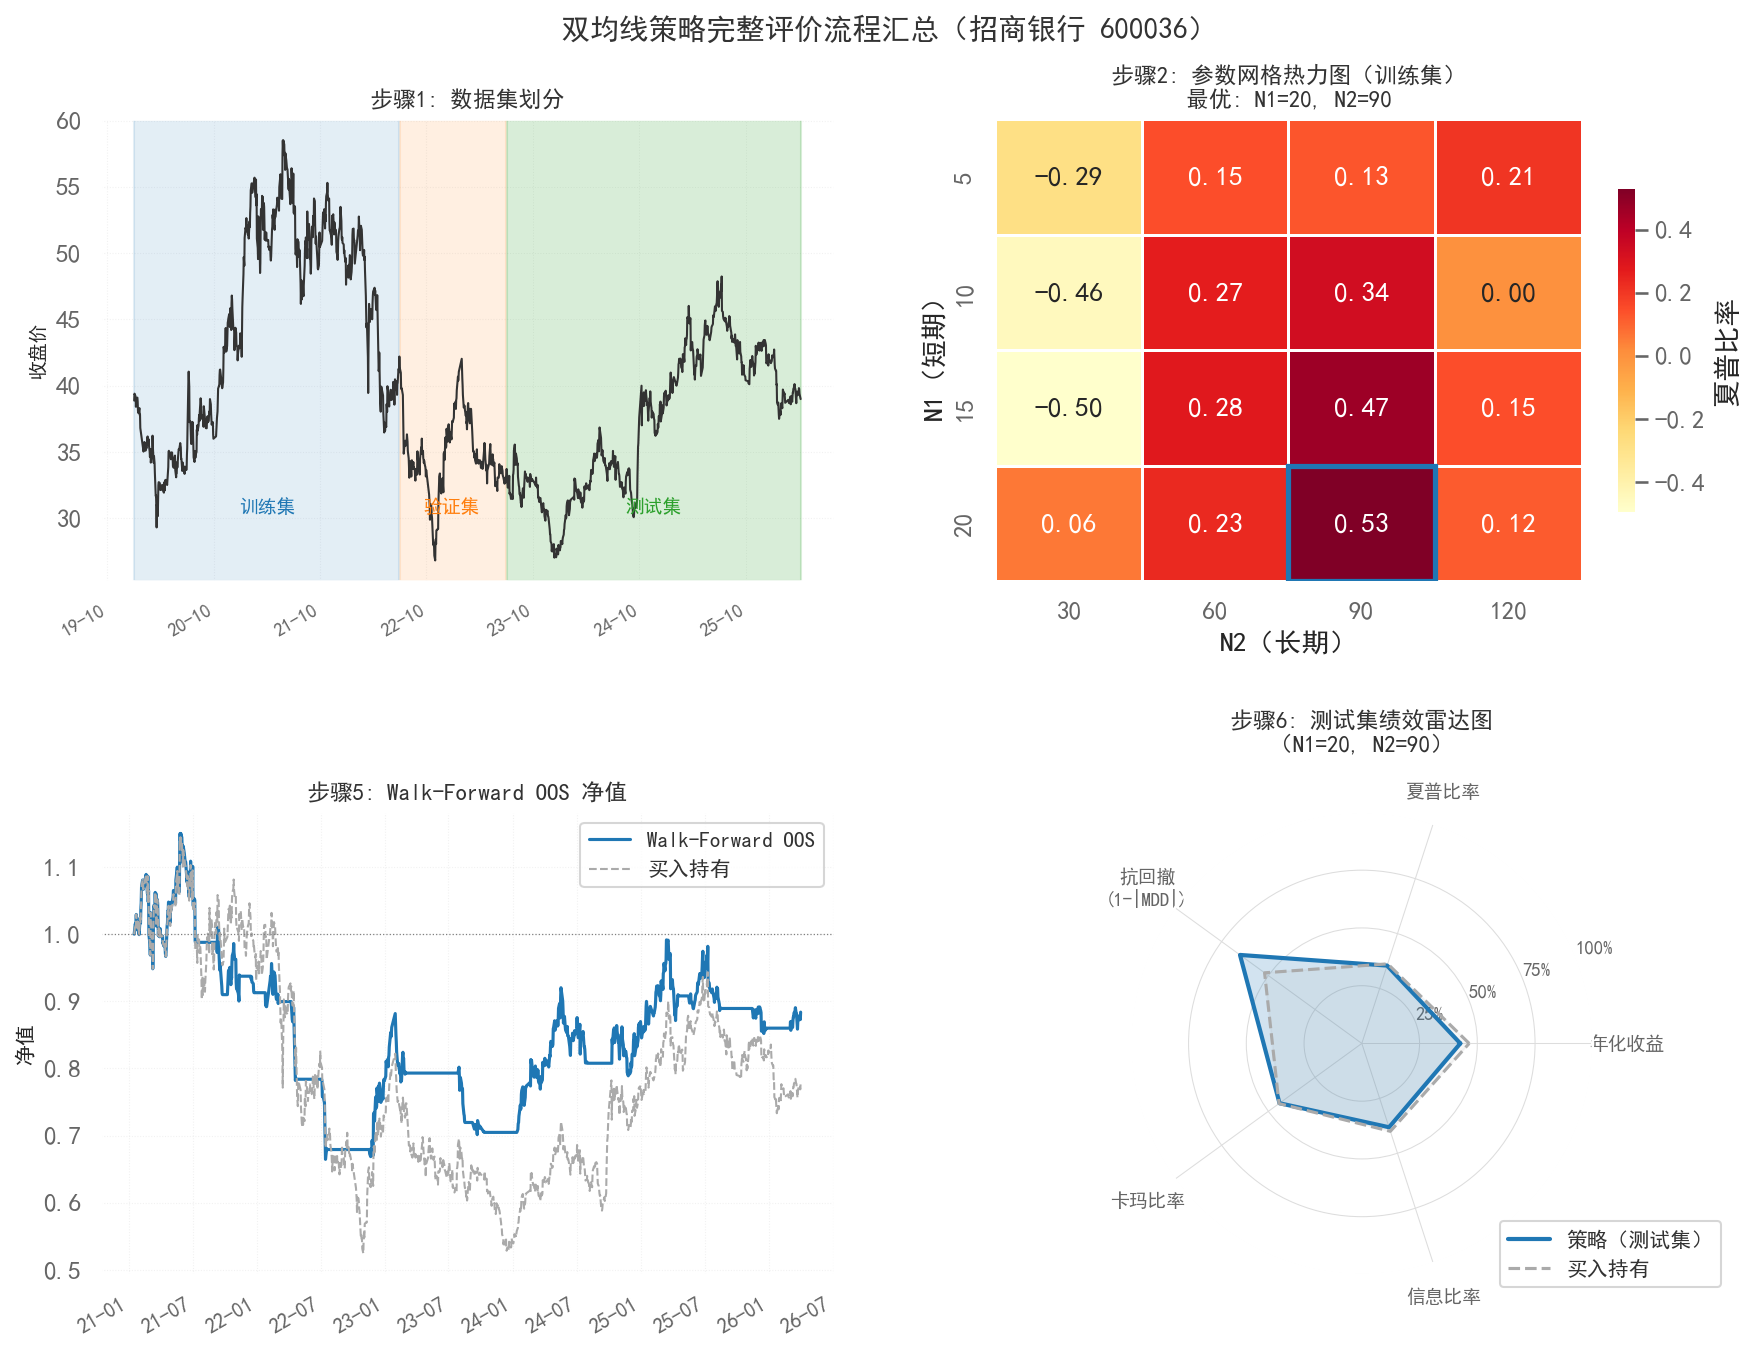

图片已保存：./figs/fig_eval_10_full_evaluation.png


In [30]:
# 中文显示设置
plt.rcParams['font.family'] = 'SimHei'  # 使用黑体中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 绘制综合评价汇总图（4子图）
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.5, wspace=0.22)

# 子图1：数据划分时间轴
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(price, color='#333', lw=1.0)
ax1.axvspan(price_train.index[0], price_train.index[-1], alpha=0.12, color='#1f77b4')
ax1.axvspan(price_valid.index[0], price_valid.index[-1], alpha=0.12, color='#ff7f0e')
ax1.axvspan(price_test.index[0],  price_test.index[-1],  alpha=0.18, color='#2ca02c')
ax1.text(price_train.index[len(price_train)//2], price.quantile(0.05),
         '训练集', ha='center', color='#1f77b4', fontsize=9, fontweight='bold')
ax1.text(price_valid.index[len(price_valid)//2], price.quantile(0.05),
         '验证集', ha='center', color='#ff7f0e', fontsize=9, fontweight='bold')
ax1.text(price_test.index[len(price_test)//2],   price.quantile(0.05),
         '测试集', ha='center', color='#2ca02c', fontsize=9, fontweight='bold')
ax1.set_title('步骤1: 数据集划分', fontsize=11)
ax1.set_ylabel('收盘价', fontsize=9)
ax1.grid(linestyle=':', alpha=0.4)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)

# 子图2：参数热力图（训练集夏普）
ax2 = fig.add_subplot(gs[0, 1])
hm_data = sharpe_grid.astype(float)
hm_data.index.name   = 'N1（短期）'
hm_data.columns.name = 'N2（长期）'
sns.heatmap(hm_data, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax2, cbar_kws={'label': '夏普比率', 'shrink': 0.7},
            linewidths=0.5)
ax2.set_title(f'步骤2: 参数网格热力图（训练集）\n最优: N1={BEST_N1}, N2={BEST_N2}', fontsize=11)
# 标注最优参数格
best_row = N1_GRID.index(BEST_N1)
best_col = N2_GRID.index(BEST_N2)
ax2.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
                              fill=False, edgecolor='#1f77b4', lw=2.5))

# 子图3：Walk-Forward OOS 净值
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(oos_nav_full.index, oos_nav_full, color='#1f77b4', lw=1.5,
         label='Walk-Forward OOS')
bnh_oos = price[oos_nav_full.index] / price[oos_nav_full.index[0]]
ax3.plot(bnh_oos.index, bnh_oos, color='#aaa', lw=1, ls='--', label='买入持有')
ax3.axhline(1, color='gray', lw=0.6, ls=':')
ax3.set_title('步骤5: Walk-Forward OOS 净值', fontsize=11)
ax3.set_ylabel('净值', fontsize=10)
ax3.legend(fontsize=10)
ax3.grid(linestyle=':', alpha=0.4)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=10)

# 子图4：测试集绩效雷达图
ax4 = fig.add_subplot(gs[1, 1], polar=True)

def normalize_metric(val, low, high):
    """将指标线性归一化到 0-1"""
    return max(0, min(1, (val - low) / (high - low + 1e-8)))

radar_labels  = ['年化收益', '夏普比率', '抗回撤\n(1-|MDD|)', '卡玛比率', '信息比率']
strat_raw  = [float(m_test['年化收益率(%)']),
              float(m_test['夏普比率']),
              100 + float(m_test['最大回撤(%)']),
              float(m_test['卡玛比率']),
              float(m_test.get('信息比率', 0))]
bnh_raw    = [float(m_bnh['年化收益率(%)']),
              float(m_bnh['夏普比率']),
              100 + float(m_bnh['最大回撤(%)']),
              float(m_bnh['卡玛比率']),
              0]
# 归一化范围
norm_ranges = [(-20, 40), (-1, 2.5), (50, 100), (-1, 2), (-1, 1.5)]
strat_norm = [normalize_metric(v, lo, hi) for v, (lo, hi) in zip(strat_raw, norm_ranges)]
bnh_norm   = [normalize_metric(v, lo, hi) for v, (lo, hi) in zip(bnh_raw, norm_ranges)]

N = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
strat_norm += strat_norm[:1]
bnh_norm   += bnh_norm[:1]
angles     += angles[:1]

ax4.plot(angles, strat_norm, color='#1f77b4', lw=2, label='策略（测试集）')
ax4.fill(angles, strat_norm, color='#1f77b4', alpha=0.2)
ax4.plot(angles, bnh_norm,   color='#aaa',    lw=1.5, ls='--', label='买入持有')
ax4.fill(angles, bnh_norm,   color='#aaa',    alpha=0.1)
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(radar_labels, fontsize=9)
ax4.set_yticks([0.25, 0.5, 0.75, 1.0])
ax4.set_yticklabels(['25%','50%','75%','100%'], fontsize=9)
ax4.set_title(f'步骤6: 测试集绩效雷达图\n（N1={BEST_N1}, N2={BEST_N2}）', fontsize=11, pad=15)
ax4.legend(fontsize=10, loc='lower right', bbox_to_anchor=(1.3, -0.05))

fig.suptitle('双均线策略完整评价流程汇总（招商银行 600036）',
             fontsize=14, y=0.95)
plt.savefig('./figs/fig_eval_10_full_evaluation.png', bbox_inches='tight')
plt.show()
print('图片已保存：./figs/fig_eval_10_full_evaluation.png')

## 全章图片清单

| 文件名 | 对应章节 | 内容 |
|--------|---------|------|
| `fig_eval_01_data_split.png` | §3.1 | 训练/验证/测试集划分时间轴 |
| `fig_eval_02_walkforward.png` | §3.1 | Walk-Forward OOS 净值 + IS/OOS 夏普散点 |
| `fig_eval_03_monthly_heatmap.png` | §3.2 | 月度收益热力图 |
| `fig_eval_04_brinson.png` | §3.3 | Brinson 归因分组柱状图 + 瀑布图 |
| `fig_eval_05_factor_attr.png` | §3.3 | 因子归因累积图（Alpha vs 因子贡献） |
| `fig_eval_06_vol_target.png` | §3.4 | 波动率目标仓位动态变化 |
| `fig_eval_07_trailing_stop.png` | §3.4 | 追踪止损三版本净值对比 |
| `fig_eval_08_rolling_sharpe.png` | §3.5 | quantstats 滚动夏普比率图 |
| `fig_eval_09_drawdowns.png` | §3.5 | quantstats 回撤深度分析 |
| `fig_eval_10_full_evaluation.png` | §3.6 | 完整评价流程汇总（4子图） |